Import all the libraries

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import operator

C:\Users\khana\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class EvaluationState(TypedDict):
    
    feedback: str = Field(description="Detailed feedback on the essay")
    score: int = Field(description="Score out of 10", ge=0, le=10)

In [5]:
structured_model = model.with_structured_output(EvaluationState)

In [6]:
essay = """
The Industrial Revolution, which took place from the 18th to 19th centuries, was a period of significant technological, socioeconomic, and cultural change. It began in Great Britain and quickly spread to other parts of the world, fundamentally transforming societies from agrarian economies to industrial powerhouses. The revolution introduced new machinery, such as the steam engine and power loom, which increased production capabilities and efficiency. This era also saw the rise of factories, urbanization, and changes in labor systems, leading to both positive advancements and challenges, including poor working conditions and environmental impacts. Overall, the Industrial Revolution laid the foundation for the modern industrialized world and continues to influence contemporary society.
"""

In [7]:
prompt = f"Evaluate the language quality of the following essay and provide detailed feedback along with a score out of 10:\n\n{essay}"
evaluation = structured_model.invoke(prompt)
print(evaluation)

{'feedback': "The essay provides a clear and concise overview of the Industrial Revolution, its key features, and its impact on society. The language is formal and academic, and the structure is logical and easy to follow. The writer uses transitional phrases and sentences to connect ideas, demonstrating a good command of cohesive devices. However, the essay could benefit from more nuanced and detailed analysis, as well as specific examples to support the claims made. Additionally, the writer could vary sentence structure and length to create a more dynamic rhythm. The use of vocabulary is adequate, but there is room for more precise and technical terms to enhance the essay's authority. Overall, the essay demonstrates a good understanding of the topic, but could be improved with more attention to depth, complexity, and linguistic variety.", 'score': 8}


In [32]:
evaluation['feedback']

"The essay provides a clear and concise overview of the Industrial Revolution, its key features, and its impact on society. The language is formal and academic, and the structure is logical and easy to follow. The writer uses transitional phrases and sentences to connect ideas, demonstrating a good command of cohesive devices. However, the essay could benefit from more nuanced and detailed analysis, as well as specific examples to support the claims made. Additionally, the writer could vary sentence structure and length to create a more dynamic rhythm. The use of vocabulary is adequate, but there is room for more precise and technical terms to enhance the essay's authority. Overall, the essay demonstrates a good understanding of the topic, but could be improved with more attention to depth, complexity, and linguistic variety."

In [33]:
evaluation['score']

8

State declaration 

In [9]:
class EssayEvaluationState(TypedDict):

    essay: str
    language_feedback: str
    depth_of_analysis_feedback: str
    clarity_of_thaught_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

Node Declaration

In [43]:
def evaluate_language(state: EssayEvaluationState):

    prompt = f"Evaluate the language quality of the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return {"language_feedback": output['feedback'], "individual_scores": [output['score']]}

In [44]:
def evaluate_depth_of_analysis(state: EssayEvaluationState):

    prompt = f"Evaluate the depth of analysis of the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return {"depth_of_analysis_feedback": output['feedback'], "individual_scores": [output['score']]}

In [45]:
def evaluate_clarity_of_thought(state: EssayEvaluationState):

    prompt = f"Evaluate the clarity of thought of the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return {"clarity_of_thaught_feedback":output['feedback'], "individual_scores": [output['score']]}

In [46]:
def final_evaluation(state: EssayEvaluationState):

    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["depth_of_analysis_feedback"]} \n clarity of thought feedback - {state["clarity_of_thaught_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [47]:
graph = StateGraph(EssayEvaluationState)

Nodes and edges addition

In [48]:
graph.add_node("language_evaluation", evaluate_language)
graph.add_node("depth_of_analysis_evaluation", evaluate_depth_of_analysis)
graph.add_node("clarity_of_thought_evaluation", evaluate_clarity_of_thought)
graph.add_node("final_evaluation", final_evaluation)



graph.add_edge(START, "language_evaluation")
graph.add_edge(START, "depth_of_analysis_evaluation")
graph.add_edge(START, "clarity_of_thought_evaluation")

graph.add_edge("language_evaluation", "final_evaluation")
graph.add_edge("depth_of_analysis_evaluation", "final_evaluation")
graph.add_edge("clarity_of_thought_evaluation", "final_evaluation")

graph.add_edge("final_evaluation", END)

Viewing and Compiling the graph

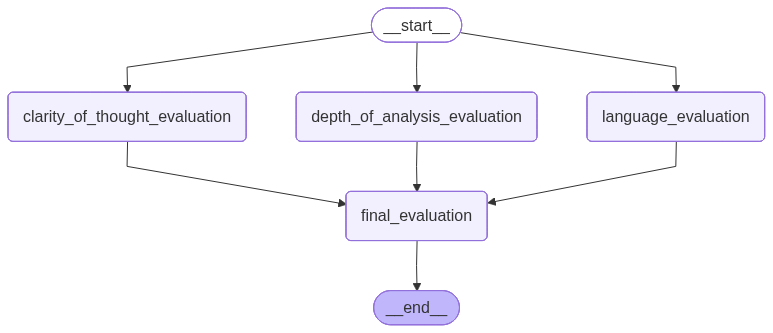

In [49]:
graph.compile()

In [50]:
workflow = graph.compile()

Execution of the graph

In [51]:
initial_state = {"essay": essay}
workflow.invoke(initial_state)

{'essay': '\nThe Industrial Revolution, which took place from the 18th to 19th centuries, was a period of significant technological, socioeconomic, and cultural change. It began in Great Britain and quickly spread to other parts of the world, fundamentally transforming societies from agrarian economies to industrial powerhouses. The revolution introduced new machinery, such as the steam engine and power loom, which increased production capabilities and efficiency. This era also saw the rise of factories, urbanization, and changes in labor systems, leading to both positive advancements and challenges, including poor working conditions and environmental impacts. Overall, the Industrial Revolution laid the foundation for the modern industrialized world and continues to influence contemporary society.\n',
 'language_feedback': 'The essay provides a clear and concise overview of the Industrial Revolution, highlighting its key features, such as technological innovations, socioeconomic change

In [52]:
essay1="""
India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society.
"""

In [53]:
initial_state = {"essay": essay1}
workflow.invoke(initial_state)

{'essay': "\nIndia in the Age of AI\nAs the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.\n\nIndia's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI fo

In [54]:
essay2= """
India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India".
"""

In [56]:
initial_state = {"essay": essay2}
workflow.invoke(initial_state)

{'essay': '\nIndia and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n

In [57]:
essay3= """
The Industrial Revolution was a big change in the world. It started in Britain in the 1700s and 1800s. People made new machines like the steam engine and power loom. These machines helped make things faster and better. Factories were built, and many people moved to cities to work there. This change made life different for many people. Some people had good jobs, but others had to work very hard in bad conditions. The Industrial Revolution also caused pollution and made the environment dirty.
"""

In [58]:
initial_state = {"essay": essay3}
workflow.invoke(initial_state)

{'essay': '\nThe Industrial Revolution was a big change in the world. It started in Britain in the 1700s and 1800s. People made new machines like the steam engine and power loom. These machines helped make things faster and better. Factories were built, and many people moved to cities to work there. This change made life different for many people. Some people had good jobs, but others had to work very hard in bad conditions. The Industrial Revolution also caused pollution and made the environment dirty.\n',
 'language_feedback': 'The essay provides a basic overview of the Industrial Revolution, including its origins in Britain, the introduction of new machines, and the impact on society. However, the language quality is simplistic and lacks depth. The essay could benefit from more complex sentence structures, varied vocabulary, and specific examples to support the claims. Additionally, the essay does not provide a clear thesis statement or conclusion, which makes it feel incomplete. Th

In [63]:
essay4= """
life is thing happning not ask to me. i wake sometimes late sometimes early but reason not clear why. world is going big fast slow same time and me stuck thinking nothing thinking all.

people say life good life bad but both mix like soup without salt sugar water. i try do better but better not coming because try also not trying. brain confuse many voice talk shout silent all together. sentence not finishing because thought finish before start.

school teach many subject like math science but no teach how think correct or why money make people angry happy sad same. money chase people people chase money nobody catch peace. peace is word but not feeling.

decision making very danger. if choose left right wrong both. if stay still also wrong. time run when want stop and stop when want run. happiness come like guest not inform leave early without bye.

dreams are sleeping always. motivation come one day then go missing forever. tomorrow promise many but today do nothing. society rule change everyday but mind still broken yesterday.

end is coming but start also not finish. life continue like loading screen never load. meaning maybe somewhere but google not found.
"""

In [64]:
initial_state = {"essay": essay4}
workflow.invoke(initial_state)

{'essay': '\nlife is thing happning not ask to me. i wake sometimes late sometimes early but reason not clear why. world is going big fast slow same time and me stuck thinking nothing thinking all.\n\npeople say life good life bad but both mix like soup without salt sugar water. i try do better but better not coming because try also not trying. brain confuse many voice talk shout silent all together. sentence not finishing because thought finish before start.\n\nschool teach many subject like math science but no teach how think correct or why money make people angry happy sad same. money chase people people chase money nobody catch peace. peace is word but not feeling.\n\ndecision making very danger. if choose left right wrong both. if stay still also wrong. time run when want stop and stop when want run. happiness come like guest not inform leave early without bye.\n\ndreams are sleeping always. motivation come one day then go missing forever. tomorrow promise many but today do nothin

In [61]:
essay5 = """
Life often feels like a continuous cycle of routines—waking up, working or studying, eating, resting, and repeating the process day after day. Many people move through this cycle without fully understanding the purpose behind it. While the world offers endless possibilities, our personal direction is not always clear.

I often find myself thinking about ambitions and goals, wanting to achieve something meaningful. However, fear and self-doubt frequently slow progress. Time behaves strangely: it seems to move quickly during busy moments, yet painfully slowly during periods of sadness or uncertainty. Happiness appears unexpectedly, but it is often brief.

Society encourages us to chase our dreams, but dreams require courage and persistence to become reality. Understanding oneself is one of the hardest challenges. The mind can be crowded with thoughts, making clarity difficult. Decisions feel overwhelming because every option carries its own risks.

We are taught many subjects through education, yet very little about how to live a balanced and peaceful life. Money provides comfort and security, but it does not guarantee inner peace. True peace must come from within, though finding it is not always easy.

Despite confusion and uncertainty, life continues. Each day arrives without pause, giving us another chance to reflect, learn, and move forward. Perhaps the meaning of life reveals itself gradually, or perhaps it is something we create along the way.
"""

In [62]:
initial_state = {"essay": essay5}
workflow.invoke(initial_state)

{'essay': '\nLife often feels like a continuous cycle of routines—waking up, working or studying, eating, resting, and repeating the process day after day. Many people move through this cycle without fully understanding the purpose behind it. While the world offers endless possibilities, our personal direction is not always clear.\n\nI often find myself thinking about ambitions and goals, wanting to achieve something meaningful. However, fear and self-doubt frequently slow progress. Time behaves strangely: it seems to move quickly during busy moments, yet painfully slowly during periods of sadness or uncertainty. Happiness appears unexpectedly, but it is often brief.\n\nSociety encourages us to chase our dreams, but dreams require courage and persistence to become reality. Understanding oneself is one of the hardest challenges. The mind can be crowded with thoughts, making clarity difficult. Decisions feel overwhelming because every option carries its own risks.\n\nWe are taught many s

##### Clarity of Thought
##### Depth of Analysis
##### Language

All the above 3 states will give two following things:
1. Detailed text feedback
2. Score(0-10)

**Final Evaluation** - will provide a summarized detailed feedback by xonsidering all the 3 states above stated and also claculate the average score of an essay by considering all the above mentioned three states scores.